In [10]:
import pandas as pd
import numpy as np

# 1. Exact paths found by the search
beijing_path = r'C:\Users\surface\Desktop\Research\.ipynb_checkpoints\beijing.csv-checkpoint.csv'
dhaka_path = r'C:\Users\surface\Desktop\Research\.ipynb_checkpoints\Dhaka.csv.csv'

# 2. Load the data
beijing_df = pd.read_csv(beijing_path)
dhaka_df = pd.read_csv(dhaka_path)

print(" Data loaded successfully.")
print("\n--- Beijing Data Sample ---")
print(beijing_df.head())

 Data loaded successfully.

--- Beijing Data Sample ---
   No  year  month  day  hour  PM2.5  PM10  SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    9.0   9.0  3.0  17.0  300.0  89.0  -0.5   
1   2  2013      3    1     1    4.0   4.0  3.0  16.0  300.0  88.0  -0.7   
2   3  2013      3    1     2    7.0   7.0  NaN  17.0  300.0  60.0  -1.2   
3   4  2013      3    1     3    3.0   3.0  5.0  18.0    NaN   NaN  -1.4   
4   5  2013      3    1     4    3.0   3.0  7.0   NaN  200.0  84.0  -1.9   

     PRES  DEWP  RAIN   wd  WSPM station  
0  1024.5 -21.4   0.0  NNW   5.7  Dongsi  
1  1025.1 -22.1   0.0   NW   3.9  Dongsi  
2  1025.3 -24.6   0.0  NNW   5.3  Dongsi  
3  1026.2 -25.5   0.0    N   4.9  Dongsi  
4  1027.1 -24.5   0.0  NNW   3.2  Dongsi  


In [9]:
import numpy as np

# Function to categorize PM2.5 into WHO health risk levels
def get_risk_level(pm25):
    if pd.isna(pm25):
        return "Unknown"
    elif pm25 <= 12:
        return "Good"
    elif pm25 <= 35.4:
        return "Moderate"
    elif pm25 <= 55.4:
        return "Unhealthy (Sensitive)"
    elif pm25 <= 150.4:
        return "Unhealthy"
    else:
        return "Hazardous"

# Apply the function to create the new feature for both cities
beijing_df['Risk_Level'] = beijing_df['PM2.5'].apply(get_risk_level)
dhaka_df['Risk_Level'] = dhaka_df['PM2.5'].apply(get_risk_level)

# Display the result to verify
print(" New 'Risk_Level' column added.\n")
print("--- Beijing Sample with Risk Level ---")
print(beijing_df[['year', 'month', 'PM2.5', 'Risk_Level']].head(10))

 New 'Risk_Level' column added.

--- Beijing Sample with Risk Level ---
   year  month  PM2.5 Risk_Level
0  2013      3    9.0       Good
1  2013      3    4.0       Good
2  2013      3    7.0       Good
3  2013      3    3.0       Good
4  2013      3    3.0       Good
5  2013      3    4.0       Good
6  2013      3    5.0       Good
7  2013      3    3.0       Good
8  2013      3    3.0       Good
9  2013      3    3.0       Good


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Comparative Analysis: Print summary statistics
print("=== COMPARATIVE AIR QUALITY STUDY: BEIJING vs. DHAKA ===\n")

# Average PM2.5 levels
print("Average PM2.5 Levels:")
print(f"Beijing: {beijing_df['PM2.5'].mean():.2f} µg/m³")
print(f"Dhaka:   {dhaka_df['PM2.5'].mean():.2f} µg/m³\n")

# Percentage of 'Hazardous' days
beijing_hazardous = (beijing_df['Risk_Level'] == 'Hazardous').mean() * 100
dhaka_hazardous = (dhaka_df['Risk_Level'] == 'Hazardous').mean() * 100

print("Percentage of 'Hazardous' Air Quality Days:")
print(f"Beijing: {beijing_hazardous:.2f}%")
print(f"Dhaka:   {dhaka_hazardous:.2f}%\n")
print("="*50)

# 2. Visualization: Compare risk levels between the two cities
plt.figure(figsize=(12, 6))

# Add a 'City' column for easier plotting
beijing_df['City'] = 'Beijing'
dhaka_df['City'] = 'Dhaka'

# Sample 1000 rows from each city for a cleaner, faster plot
combined_df = pd.concat([beijing_df.sample(1000, random_state=42), 
                         dhaka_df.sample(1000, random_state=42)])

# Create a count plot comparing risk levels
sns.countplot(data=combined_df, x='Risk_Level', hue='City', 
              order=['Good', 'Moderate', 'Unhealthy (Sensitive)', 'Unhealthy', 'Hazardous', 'Unknown'])

plt.title('Comparison of Air Quality Risk Levels: Beijing vs. Dhaka', fontsize=14, fontweight='bold')
plt.xlabel('WHO Health Risk Level', fontsize=12)
plt.ylabel('Number of Days (Sampled)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='City')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

=== COMPARATIVE AIR QUALITY STUDY: BEIJING vs. DHAKA ===

Average PM2.5 Levels:
Beijing: 86.19 µg/m³
Dhaka:   105.50 µg/m³



KeyError: 'Risk_Level'

=== COMPARATIVE AIR QUALITY STUDY: BEIJING vs. DHAKA ===

Average PM2.5 Levels:
Beijing: 86.19 µg/m³
Dhaka:   105.50 µg/m³

Percentage of 'Hazardous' Air Quality Days:
Beijing: 16.94%
Dhaka:   20.91%



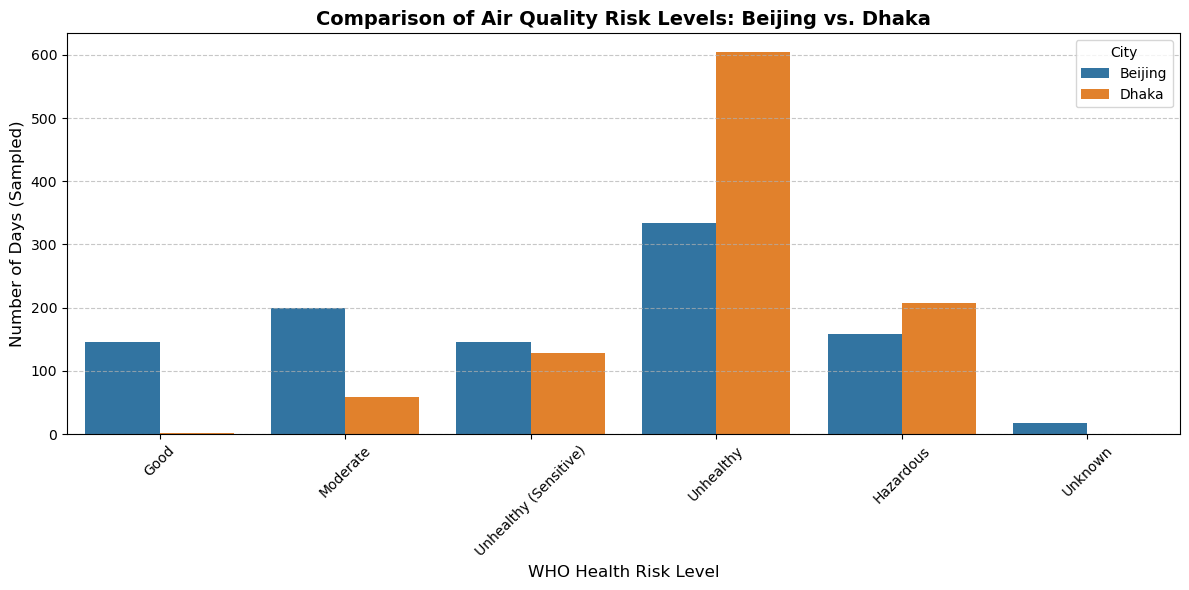

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data from exact paths
beijing_path = r'C:\Users\surface\Desktop\Research\.ipynb_checkpoints\beijing.csv-checkpoint.csv'
dhaka_path = r'C:\Users\surface\Desktop\Research\.ipynb_checkpoints\Dhaka.csv.csv'

beijing_df = pd.read_csv(beijing_path)
dhaka_df = pd.read_csv(dhaka_path)

# 2. Create Risk Level feature
def get_risk_level(pm25):
    if pd.isna(pm25): return "Unknown"
    elif pm25 <= 12: return "Good"
    elif pm25 <= 35.4: return "Moderate"
    elif pm25 <= 55.4: return "Unhealthy (Sensitive)"
    elif pm25 <= 150.4: return "Unhealthy"
    else: return "Hazardous"

beijing_df['Risk_Level'] = beijing_df['PM2.5'].apply(get_risk_level)
dhaka_df['Risk_Level'] = dhaka_df['PM2.5'].apply(get_risk_level)

# 3. Print comparative stats
print("=== COMPARATIVE AIR QUALITY STUDY: BEIJING vs. DHAKA ===\n")
print("Average PM2.5 Levels:")
print(f"Beijing: {beijing_df['PM2.5'].mean():.2f} µg/m³")
print(f"Dhaka:   {dhaka_df['PM2.5'].mean():.2f} µg/m³\n")

beijing_hazardous = (beijing_df['Risk_Level'] == 'Hazardous').mean() * 100
dhaka_hazardous = (dhaka_df['Risk_Level'] == 'Hazardous').mean() * 100
print("Percentage of 'Hazardous' Air Quality Days:")
print(f"Beijing: {beijing_hazardous:.2f}%")
print(f"Dhaka:   {dhaka_hazardous:.2f}%\n")
print("="*50)

# 4. Visualization
plt.figure(figsize=(12, 6))
beijing_df['City'] = 'Beijing'
dhaka_df['City'] = 'Dhaka'
combined_df = pd.concat([beijing_df.sample(1000, random_state=42), dhaka_df.sample(1000, random_state=42)])

sns.countplot(data=combined_df, x='Risk_Level', hue='City', 
              order=['Good', 'Moderate', 'Unhealthy (Sensitive)', 'Unhealthy', 'Hazardous', 'Unknown'])

plt.title('Comparison of Air Quality Risk Levels: Beijing vs. Dhaka', fontsize=14, fontweight='bold')
plt.xlabel('WHO Health Risk Level', fontsize=12)
plt.ylabel('Number of Days (Sampled)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='City')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()